# Two Lines Through Temperature Data

**Least-Squares Trend Lines and PCA Principal Directions on Climate Data**

**Project Members**

| Name | SRN |
|---|---|
| Prajwal M M | PES1UG25CS370 |
| Navneeth Suresh | PES1UG25CS326 |
| Nikhil Reddy | PES1UG25CS340 |
| Nikhil Kiran | PES1UG25CS338 |

---

## 1. Problem Statement

> "Plot a small set of year-temperature points; fit a least-squares trend line
> and find a principal direction using PCA. Compare what the lines represent."

This combines the ideas of Project 8 (interpolation and climate change, via the
orthogonal-projection least-squares method) and Project 11 (projections,
eigenvectors, and PCA).

## 2. Objective

To compute two different "best" lines through the same 2D data and to
understand, from first principles, why they answer different questions.

## 3. Notebook Roadmap

1. Setup and imports
2. Dataset
3. Matrix representation
4. Least squares via orthogonal projection
5. PCA by hand
6. Angle between the two directions
7. Visualizations (six figures)
8. Comparison and conclusion

## 4. Setup

We only need three libraries:

- `numpy` for all matrix operations
- `scipy.linalg.orth` to get an orthonormal basis of a column space
- `matplotlib` for plotting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orth

# Render figures inline and give them a consistent, readable size
%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4.5)

## 5. Dataset

A 12-year subset (2013 to 2024) of the annual global-mean land-ocean
temperature anomaly from the NASA GISTEMP v4 analysis. Values are deviations
from the 1951-1980 mean, in degrees Celsius.

Source: `https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv`
(year column, `J-D` annual mean).

The points are not perfectly collinear, so both the least-squares fit and the
PCA direction are meaningful.

In [2]:
def load_data():
    # Return the (year, temperature anomaly) pairs as two float arrays.
    # Floats are used for both so that later matrix products stay numerically uniform.
    years = np.array([2013, 2014, 2015, 2016, 2017, 2018,
                      2019, 2020, 2021, 2022, 2023, 2024], dtype=float)
    temperature = np.array([0.68, 0.75, 0.90, 1.01, 0.92, 0.85,
                            0.98, 1.01, 0.85, 0.89, 1.17, 1.29], dtype=float)
    return years, temperature


years, temperature = load_data()
print(f"Number of observations: {len(years)}")

Number of observations: 12


## 6. Matrix Representation

**Data matrix** `X`: each row is one observation `(year, temperature)`. PCA works
on this matrix because it treats both coordinates symmetrically.

```
X = [[year_1, temp_1],
     [year_2, temp_2],
     ...
     [year_n, temp_n]]
```

**Design matrix** `B` and **target vector** `t` for the linear model
`temp ~ c + m * year`:

```
B = [[1, year_1], [1, year_2], ..., [1, year_n]]   (n x 2)
t = [temp_1, ..., temp_n]^T                        (n x 1)
```

The system `B beta ~ t` with `beta = [c, m]^T` is generally inconsistent (there
is no single line through every point), which is exactly why we need least
squares.

In [3]:
def matrix_representation(years, temperature):
    # Build the three matrices used throughout the notebook.
    #   X : data matrix, one row per (year, temperature) observation
    #   B : design matrix, a column of ones (intercept) next to the years (slope)
    #   t : target vector of temperatures
    X = np.column_stack((years, temperature))
    n = len(years)
    B = np.column_stack((np.ones(n), years))
    t = temperature.copy()
    return X, B, t


X, B, t = matrix_representation(years, temperature)
print("X shape:", X.shape)
print("B shape:", B.shape)
print("t shape:", t.shape)

X shape: (12, 2)
B shape: (12, 2)
t shape: (12,)


## 7. Least Squares via Orthogonal Projection

We solve

```
min over beta  of  || B beta - t ||^2
```

**Geometric interpretation (Project 8).** The fitted values `t_hat` are the
orthogonal projection of `t` onto the column space of `B`:

1. `Q = orth(B)` is an orthonormal basis for `col(B)`, so `Q^T Q ~ I`.
2. `P = Q Q^T` is the orthogonal projection matrix. It is idempotent
   (`P^2 ~ P`) and symmetric (`P^T = P`).
3. `t_hat = P t` is the vector in `col(B)` closest to `t`.

Since `t_hat` lies in `col(B)`, there exists a `beta = [c, m]^T` with
`B beta = t_hat`. We extract it with `np.linalg.lstsq`. The fitted line is

```
temperature ~ m * year + c
```

Residuals are measured **vertically** (difference in temperature at the same
year). SSE, RMSE and R squared are all computed from them.

In [4]:
def least_squares_analysis(years, temperature, B, t):
    # --- Step 1 to 3: projection onto the column space of B ---
    Q = orth(B)          # orthonormal basis of col(B)
    P = Q @ Q.T          # projector onto col(B)
    t_hat = P @ t        # closest vector to t inside col(B)

    # --- Sanity checks on the projection machinery ---
    # Q^T Q should be the identity (orthonormal columns)
    err_orth = np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]))
    # P @ P should equal P (projecting twice changes nothing)
    err_idem = np.linalg.norm(P @ P - P)
    # Project 8 check: Q spans the same space as B, so stacking Q next to B
    # must not increase the rank
    rank_QB = (np.linalg.matrix_rank(Q),
               np.linalg.matrix_rank(np.column_stack((Q, B))))

    # --- Recover the slope and intercept that produce t_hat ---
    beta, *_ = np.linalg.lstsq(B, t, rcond=None)
    c, m = beta[0], beta[1]

    # --- Goodness-of-fit metrics from the vertical residuals ---
    predicted = m * years + c
    residuals = temperature - predicted
    sse = np.sum(residuals ** 2)                              # sum of squared errors
    rmse = np.sqrt(np.mean(residuals ** 2))                   # root mean squared error
    ss_tot = np.sum((temperature - np.mean(temperature)) ** 2)  # total variance
    r2 = 1 - sse / ss_tot                                     # coefficient of determination

    return {"c": c, "m": m, "Q": Q, "P": P, "t_hat": t_hat,
            "predicted": predicted, "residuals": residuals,
            "sse": sse, "rmse": rmse, "r2": r2,
            "err_orth": err_orth, "err_idem": err_idem, "rank_QB": rank_QB}


ls = least_squares_analysis(years, temperature, B, t)

print(f"Fitted line : T = {ls['m']:.5f} * Year + ({ls['c']:.3f})")
print(f"SSE         : {ls['sse']:.5f}")
print(f"RMSE        : {ls['rmse']:.5f}")
print(f"R squared   : {ls['r2']:.5f}")
print(f"||Q^T Q - I|| : {ls['err_orth']:.2e}")
print(f"||P^2 - P||   : {ls['err_idem']:.2e}")
print(f"rank(Q), rank([Q B]) : {ls['rank_QB']}")

Fitted line : T = 0.03503 * Year + (-69.776)
SSE         : 0.13564
RMSE        : 0.10632
R squared   : 0.56409
||Q^T Q - I|| : 2.62e-16
||P^2 - P||   : 3.24e-16
rank(Q), rank([Q B]) : (np.int64(2), np.int64(2))


## 8. PCA by Hand

PCA finds the direction along which the data varies the most. We build it from
the covariance matrix instead of calling a library routine:

1. Center the data: `Z = X - mu`, where `mu` is the mean of each column.
2. Covariance matrix: `C = (1/(n-1)) Z^T Z` (2x2 and symmetric).
3. Eigenpairs of `C` from `np.linalg.eigh`. Because `C` is symmetric the
   eigenvalues are real and the eigenvectors are orthogonal.
4. Sort by eigenvalue, descending. The largest `lambda_1` gives `v1`, the
   principal direction, with `||v1|| ~ 1` and `v1 . v2 ~ 0`.
5. PCA line: `x(s) = mu + s * v1`, which always passes through the centroid.
6. Each centered point projects as `(z_i . v1) v1`. Translating back by `mu`
   gives the foot-of-perpendicular points on the PCA line.

**Explained variance ratio** is `lambda_1 / (lambda_1 + lambda_2)`, the fraction
of total 2D variance lying along `v1`.

In [5]:
def pca_analysis(X):
    # --- Step 1: center the data around its centroid ---
    mu = np.mean(X, axis=0)
    Z = X - mu
    n = X.shape[0]

    # --- Step 2: sample covariance matrix (symmetric 2x2) ---
    C = (Z.T @ Z) / (n - 1)

    # --- Step 3 and 4: eigendecomposition, sorted by eigenvalue (descending) ---
    # eigh is the right solver here because C is symmetric
    eigenvalues, eigenvectors = np.linalg.eigh(C)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    v1, v2 = eigenvectors[:, 0], eigenvectors[:, 1]   # principal / secondary direction
    explained = eigenvalues[0] / np.sum(eigenvalues)  # variance captured by v1

    # --- Step 6: orthogonal projection of every point onto the PCA line ---
    projected = mu + np.array([(z @ v1) * v1 for z in Z])

    return {"mu": mu, "Z": Z, "C": C, "eigenvalues": eigenvalues,
            "eigenvectors": eigenvectors, "v1": v1, "v2": v2,
            "explained": explained, "projected": projected}


def pca_parametric_line(X, mu, v1):
    # Step 5: sample the line x(s) = mu + s * v1.
    # s is the signed distance of each point along v1; we extend the range by
    # 25 percent on each side so the line visibly extends past the data.
    s = (X - mu) @ v1
    pad = 0.25 * (s.max() - s.min())
    s_line = np.linspace(s.min() - pad, s.max() + pad, 100)
    line = mu[:, None] + np.outer(v1, s_line)
    return line[0], line[1]


pca = pca_analysis(X)
line_x, line_y = pca_parametric_line(X, pca["mu"], pca["v1"])

print("Centroid mu      :", np.round(pca["mu"], 4))
print("Covariance matrix:\n", np.round(pca["C"], 5))
print("Eigenvalues      :", np.round(pca["eigenvalues"], 5))
print("Principal dir v1 :", np.round(pca["v1"], 5))
print(f"||v1||           : {np.linalg.norm(pca['v1']):.4f}")
print(f"v1 . v2          : {pca['v1'] @ pca['v2']:.2e}")
print(f"Explained var.   : {pca['explained'] * 100:.2f}%")

Centroid mu      : [2.0185e+03 9.4170e-01]
Covariance matrix:
 [[13.       0.45545]
 [ 0.45545  0.02829]]
Eigenvalues      : [1.301597e+01 1.232000e-02]
Principal dir v1 : [-0.99939 -0.03505]
||v1||           : 1.0000
v1 . v2          : 1.37e-18
Explained var.   : 99.91%


## 9. Angle Between the Two Directions

The least-squares line has direction `(1, m)` in the (year, temperature) plane.
The PCA line has direction `v1`. The angle between them tells us how far apart
the two answers are.

We take the absolute value of the dot product because an eigenvector is only
defined up to sign (`v1` and `-v1` describe the same line).

In [6]:
def angle_between(ls, pca):
    # Unit direction of the least-squares line
    d_ls = np.array([1.0, ls["m"]])
    d_ls /= np.linalg.norm(d_ls)

    # Unit direction of the PCA line
    d_pca = pca["v1"] / np.linalg.norm(pca["v1"])

    # abs() removes the sign ambiguity; clip() guards arccos against rounding
    cos_theta = np.clip(abs(d_ls @ d_pca), -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))


theta_deg = angle_between(ls, pca)
print(f"Angle between LS and PCA directions: {theta_deg:.4f} degrees")

Angle between LS and PCA directions: 0.0019 degrees


## 10. Visualizations

Six figures, in order:

1. Original data
2. Numerical results table
3. Least-squares trend line (vertical errors)
4. PCA principal direction
5. PCA projections (perpendicular errors)
6. Side-by-side comparison

### Figure 1: Original Data

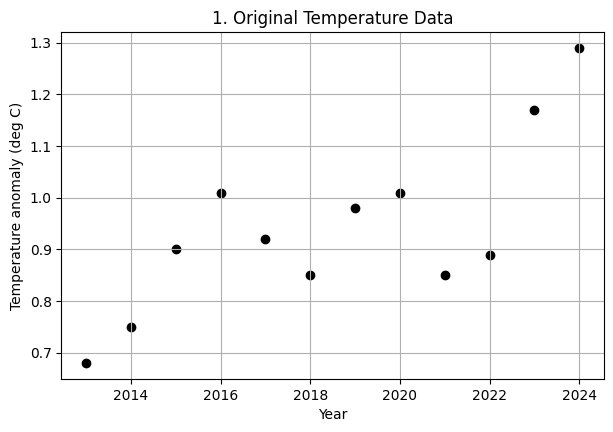

In [7]:
def plot_data(years, temperature):
    # Plain scatter of the raw observations
    plt.figure()
    plt.scatter(years, temperature, color="black")
    plt.title("1. Original Temperature Data")
    plt.xlabel("Year")
    plt.ylabel("Temperature anomaly (deg C)")
    plt.grid(True)
    plt.show()


plot_data(years, temperature)

### Figure 2: Numerical Results

A single table summarizing both methods, followed by a short note on what each
method optimizes. The projection checks (`||Q^T Q - I||`, `||P^2 - P||`) should
be near machine precision, and `v1 . v2` should be near zero.

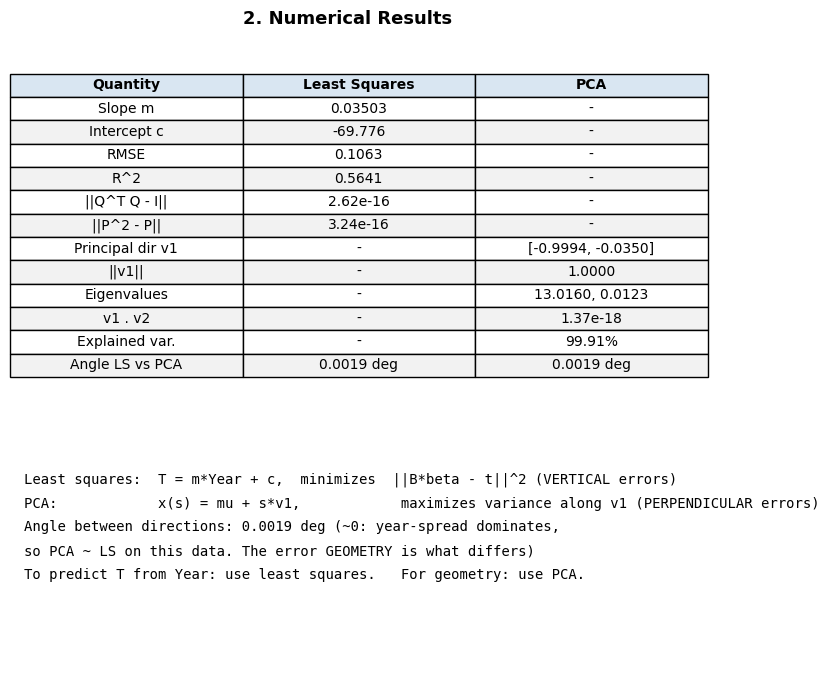

In [8]:
def plot_results(ls, pca, theta_deg):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                   gridspec_kw={"height_ratios": [1.6, 1],
                                                "hspace": 0.15})
    fig.subplots_adjust(top=0.93, bottom=0.03)
    for ax in (ax1, ax2):
        ax.axis("off")   # both axes are only canvases for the table and the text

    # ---- Top: metric table (one row per quantity, one column per method) ----
    rows = [
        ["Slope m",          f"{ls['m']:.5f}",         "-"],
        ["Intercept c",      f"{ls['c']:.3f}",         "-"],
        ["RMSE",             f"{ls['rmse']:.4f}",      "-"],
        ["R^2",              f"{ls['r2']:.4f}",        "-"],
        ["||Q^T Q - I||",    f"{ls['err_orth']:.2e}",  "-"],
        ["||P^2 - P||",      f"{ls['err_idem']:.2e}",  "-"],
        ["Principal dir v1", "-", f"[{pca['v1'][0]:.4f}, {pca['v1'][1]:.4f}]"],
        ["||v1||",           "-", f"{np.linalg.norm(pca['v1']):.4f}"],
        ["Eigenvalues",      "-", f"{pca['eigenvalues'][0]:.4f}, {pca['eigenvalues'][1]:.4f}"],
        ["v1 . v2",          "-", f"{pca['v1'] @ pca['v2']:.2e}"],
        ["Explained var.",   "-", f"{pca['explained'] * 100:.2f}%"],
        ["Angle LS vs PCA",  f"{theta_deg:.4f} deg", f"{theta_deg:.4f} deg"],
    ]
    tbl = ax1.table(cellText=rows,
                    colLabels=["Quantity", "Least Squares", "PCA"],
                    loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.4)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#d9e6f2")        # header row
            cell.set_text_props(weight="bold")
        elif r % 2 == 0:
            cell.set_facecolor("#f2f2f2")        # zebra striping for readability
    fig.suptitle("2. Numerical Results", y=0.98, fontsize=13, weight="bold")

    # ---- Bottom: plain-language summary of what each method does ----
    text = (
        "Least squares:  T = m*Year + c,  minimizes  ||B*beta - t||^2 (VERTICAL errors)\n"
        "PCA:            x(s) = mu + s*v1,            maximizes variance along v1 (PERPENDICULAR errors)\n"
        f"Angle between directions: {theta_deg:.4f} deg (~0: year-spread dominates,\n"
        "so PCA ~ LS on this data. The error GEOMETRY is what differs)\n"
        "To predict T from Year: use least squares.   For geometry: use PCA."
    )
    ax2.text(0.02, 0.90, text, va="top", family="monospace",
             fontsize=10, linespacing=1.9)
    plt.show()


plot_results(ls, pca, theta_deg)

### Figure 3: Least-Squares Trend Line

The gray segments are the **vertical** residuals. Least squares minimizes the
sum of their squares.

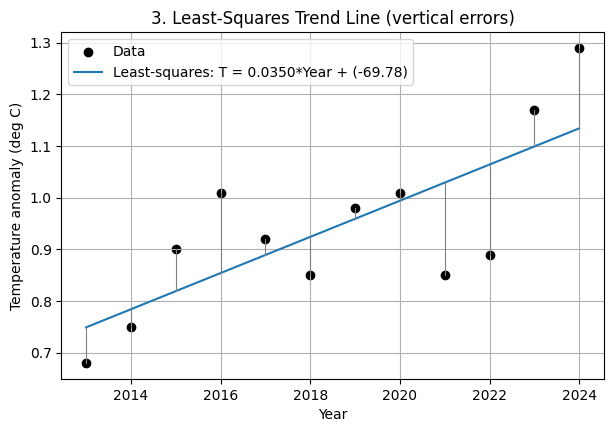

In [9]:
def plot_least_squares(years, temperature, ls):
    plt.figure()
    plt.scatter(years, temperature, color="black", label="Data")
    plt.plot(years, ls["predicted"], color="tab:blue",
             label=f"Least-squares: T = {ls['m']:.4f}*Year + ({ls['c']:.2f})")

    # Draw each residual as a vertical segment from the data point to the line
    for y, a, p in zip(years, temperature, ls["predicted"]):
        plt.plot([y, y], [a, p], color="gray", linewidth=0.8)

    plt.title("3. Least-Squares Trend Line (vertical errors)")
    plt.xlabel("Year")
    plt.ylabel("Temperature anomaly (deg C)")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_least_squares(years, temperature, ls)

### Figure 4: PCA Principal Direction

The red line passes through the centroid `mu` (red cross) and points along the
direction of greatest variance.

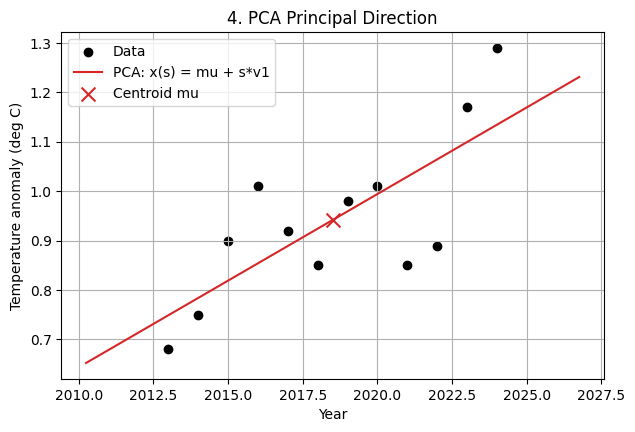

In [10]:
def plot_pca(years, temperature, pca, line_x, line_y):
    plt.figure()
    plt.scatter(years, temperature, color="black", label="Data")
    plt.plot(line_x, line_y, color="tab:red", label="PCA: x(s) = mu + s*v1")
    plt.scatter([pca["mu"][0]], [pca["mu"][1]], color="tab:red",
                marker="x", s=100, label="Centroid mu")
    plt.title("4. PCA Principal Direction")
    plt.xlabel("Year")
    plt.ylabel("Temperature anomaly (deg C)")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_pca(years, temperature, pca, line_x, line_y)

### Figure 5: PCA Projections

Each purple point is the foot of the perpendicular from a data point onto the
PCA line. The gray segments are the **perpendicular** errors that PCA
minimizes. Note the contrast with the vertical segments in Figure 3.

Because the axes have very different scales (years span about 11 units while
temperature spans about 0.6), the perpendicular segments can look slanted
rather than at a right angle on screen. They are exactly perpendicular in the
data coordinates.

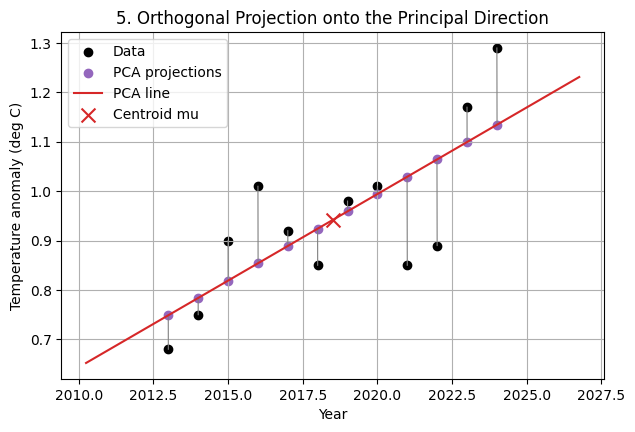

In [11]:
def plot_pca_projections(years, temperature, X, pca, line_x, line_y):
    plt.figure()
    plt.scatter(years, temperature, color="black", label="Data")
    plt.scatter(pca["projected"][:, 0], pca["projected"][:, 1],
                color="tab:purple", label="PCA projections")

    # Connect each original point to its projection on the PCA line
    for (x0, y0), (x1, y1) in zip(X, pca["projected"]):
        plt.plot([x0, x1], [y0, y1], color="gray", linewidth=0.8)

    plt.plot(line_x, line_y, color="tab:red", label="PCA line")
    plt.scatter([pca["mu"][0]], [pca["mu"][1]], color="tab:red",
                marker="x", s=100, label="Centroid mu")
    plt.title("5. Orthogonal Projection onto the Principal Direction")
    plt.xlabel("Year")
    plt.ylabel("Temperature anomaly (deg C)")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_pca_projections(years, temperature, X, pca, line_x, line_y)

### Figure 6: Comparison, Least Squares vs PCA

Both lines pass through the centroid. On this dataset they nearly overlap
because the year spread dominates the covariance matrix.

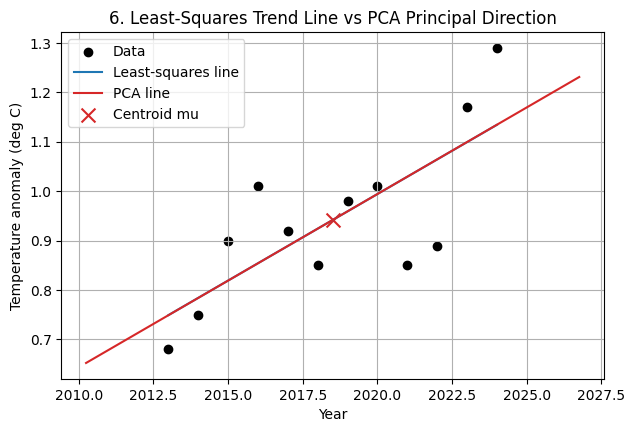

In [12]:
def plot_comparison(years, temperature, ls, pca, line_x, line_y):
    plt.figure()
    plt.scatter(years, temperature, color="black", label="Data")
    plt.plot(years, ls["predicted"], color="tab:blue", label="Least-squares line")
    plt.plot(line_x, line_y, color="tab:red", label="PCA line")
    plt.scatter([pca["mu"][0]], [pca["mu"][1]], color="tab:red",
                marker="x", s=100, label="Centroid mu")
    plt.title("6. Least-Squares Trend Line vs PCA Principal Direction")
    plt.xlabel("Year")
    plt.ylabel("Temperature anomaly (deg C)")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_comparison(years, temperature, ls, pca, line_x, line_y)

## 11. Optional Experiment: Standardized Axes

The comparison below explains why the two lines nearly coincide: in raw units
the year axis dominates the variance. If both variables are standardized
(zero mean, unit variance), the two lines should rotate apart visibly. This
cell is an extra check and is not part of the original script.

Angle LS vs PCA (raw units)     : 0.0019 deg
Angle LS vs PCA (standardized)  : 8.0913 deg


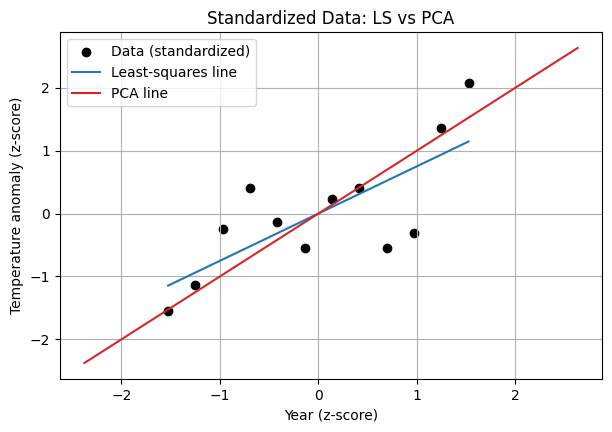

In [13]:
# Standardize both columns so neither axis dominates the covariance matrix
X_std = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
years_std, temp_std = X_std[:, 0], X_std[:, 1]

# Rerun both methods on the standardized data
_, B_std, t_std = matrix_representation(years_std, temp_std)
ls_std = least_squares_analysis(years_std, temp_std, B_std, t_std)
pca_std = pca_analysis(X_std)
lx, ly = pca_parametric_line(X_std, pca_std["mu"], pca_std["v1"])

print(f"Angle LS vs PCA (raw units)     : {theta_deg:.4f} deg")
print(f"Angle LS vs PCA (standardized)  : {angle_between(ls_std, pca_std):.4f} deg")

plt.figure()
plt.scatter(years_std, temp_std, color="black", label="Data (standardized)")
plt.plot(years_std, ls_std["predicted"], color="tab:blue", label="Least-squares line")
plt.plot(lx, ly, color="tab:red", label="PCA line")
plt.title("Standardized Data: LS vs PCA")
plt.xlabel("Year (z-score)")
plt.ylabel("Temperature anomaly (z-score)")
plt.legend()
plt.grid(True)
plt.show()

## 12. Comparison

| Aspect | Least squares | PCA |
|---|---|---|
| Question | Best predict `T` from `year` | Direction of maximum variance |
| Error minimized | Vertical (squared) | Perpendicular (reconstruction) |
| Variables | Asymmetric (`year` in, `T` out) | Symmetric |
| Line passes through | The centroid (x_bar, y_bar) | Always the centroid mu |
| Use for | Prediction, trend | Geometry, dimensionality reduction |

The two directions make only a small angle with each other when the data is
approximately linear along a well-defined trend, but they coincide only
accidentally. They are obtained from different optimization problems. With raw
units, the year spread dominates the covariance matrix, so the two fitted
slopes nearly coincide (angle near 0 degrees on the GISTEMP subset). The
conceptual difference is visible in the error geometry: vertical residual
segments for least squares versus perpendicular projection segments for PCA.
If year and temperature are standardized to comparable scales, the two lines
rotate apart visibly (see the optional experiment above).

## 13. Conclusion

Least squares draws the line of best *prediction*. PCA draws the line of best
*description* of the cloud. Both are pure linear algebra: orthogonal projection
onto a column space, and eigenvectors of a covariance matrix.

## 14. How to Run

Dependencies: `numpy`, `scipy`, `matplotlib`, plus `jupyter` to open the notebook.

```bash
pip install numpy scipy matplotlib jupyter
jupyter notebook two_lines_temperature.ipynb
```

Then choose **Kernel > Restart & Run All**.

## 15. License

Released under the MIT License.